In [1]:
import os
import sys
import scanpy as sc
import scvi
import mudata as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Last run with scvi-tools version:", scvi.__version__)
scvi.settings.num_threads = 48
scvi.settings.seed = 0
sc._settings.ScanpyConfig.n_jobs=16
sc.settings.verbosity = 1

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Impo

Last run with scvi-tools version: 1.2.0


In [2]:
sc.logging.print_header()

Package,Version
scanpy,1.11.0
scvi-tools,1.2.0
mudata,0.3.1
numpy,1.26.4
pandas,2.2.3
matplotlib,3.9.2
Component,Info
Python,"3.12.6 | packaged by conda-forge | (main, Sep 30 2024, 18:08:52) [GCC 13.3.0]"
OS,Linux-5.15.0-134-generic-x86_64-with-glibc2.31
CPU,"96 logical CPU cores, x86_64"


# 1. Run on NVIDIA A100 or V100 GPU or CPU

In [3]:
obj_path = '/home/liyanguo/MyImmuCell/04_Ref_Atlas_scVI/'

In [4]:
#dataset = sys.argv[1]
dataset = "Ref_Atlas"

In [5]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_preprocess_scVI.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 888260 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'scDblFinder.class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'High_quality', 'Batch'
    var: 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    lay

In [7]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key ="Batch",
    continuous_covariate_keys=["nCount_RNA", "percent_mito"]
)

In [8]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

In [9]:
#notic 6M cell take 8h with batch size 4096 in CPU device
model.train(accelerator="cpu",
            max_epochs=400,batch_size=4096)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=95` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [10]:
model.save(obj_path, overwrite=True, prefix=f'{dataset}_scRNA_scVI_')

# 2. Get_latent_representation

In [11]:
X_scVI = model.get_latent_representation()

In [12]:
np.save(f"{obj_path}{dataset}_X_scVI",X_scVI)

# 3. Get model parameter

In [13]:
sheet=pd.DataFrame()
for key in model.history.keys():
    temp = model.history[key]
    temp = temp.reset_index()
    sheet=pd.concat([sheet,temp],axis=1)

In [14]:
pd.DataFrame.to_csv(sheet,f"{obj_path}{dataset}_scVI_model_history.csv")

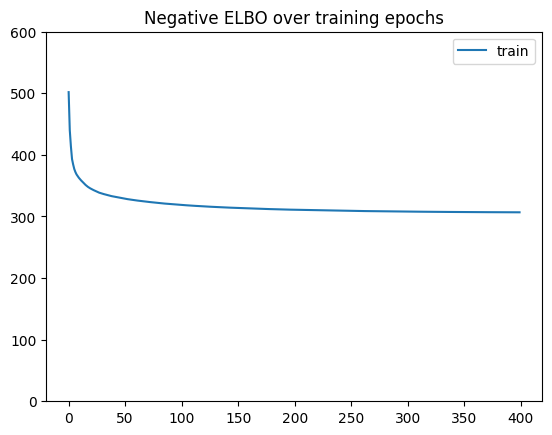

In [15]:
fig, ax = plt.subplots(1, 1)
sheet["elbo_train"].plot(ax=ax, label="train")
ax.set(title="Negative ELBO over training epochs", ylim=(0, 600))
ax.legend()
plt.savefig(f"{obj_path}{dataset}_ELBO.png")